In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

import jax
import jax.numpy as jnp

import importlib, os
import east
importlib.reload(east)

plt.rcParams['figure.dpi'] = 120


## Temperature pooled DMD comparison

Repeat the pooled single-site DMD workflow at fixed walker count for four temperatures, using the ACF-derived two-tau window at each temperature.


In [4]:
key = jax.random.PRNGKey(11)

# Temperature sweep by equilibrium length scale.
l_tests = [3, 4, 6, 8]
n_walkers = 2048

# Keep the same simulation scale as DMD_n_walkers.ipynb.
N = 256
n_configs = 16
n_records = 500

if not os.path.exists('acf_results.npy'):
    raise FileNotFoundError('acf_results.npy is required so each run can use a 2*tau_ACF window')

acf_results = np.load('acf_results.npy', allow_pickle=True).item()
missing = [l_test for l_test in l_tests if l_test not in acf_results or 'tau' not in acf_results[l_test]]
if missing:
    raise KeyError(f'acf_results.npy is missing tau_ACF entries for l={missing}')

temperature_params = {}
for l_test in l_tests:
    T = float(east.temperature_from_length(l_test))
    c_eq = float(east.concentration(T))
    tau_acf_ref = float(acf_results[l_test]['tau'])
    dt_record = tau_acf_ref / 250
    times = np.arange(n_records + 1) * dt_record
    mu_micro = -np.exp(-1.0 / T)

    temperature_params[l_test] = {
        'T': T,
        'c_eq': c_eq,
        'tau_acf_ref': tau_acf_ref,
        'dt_record': dt_record,
        'times': times,
        'T_window': times[-1],
        'mu_micro': mu_micro,
    }

    print(
        f'l={l_test}, T={T:.4f}, c_eq={c_eq:.4f}, '
        f'dt={dt_record:.4g}, max_t={times[-1]:.2f} ({times[-1] / tau_acf_ref:.2f} tau_acf), '
        f'Re(mu_micro)={mu_micro:.5g}'
    )

print(f'N={N}, configs={n_configs}, walkers/config={n_walkers}')


l=3, T=1.4427, c_eq=0.3333, dt=0.04279, max_t=21.40 (2.00 tau_acf), Re(mu_micro)=-0.5
l=4, T=0.9102, c_eq=0.2500, dt=0.1798, max_t=89.88 (2.00 tau_acf), Re(mu_micro)=-0.33333
l=6, T=0.6213, c_eq=0.1667, dt=1.329, max_t=664.75 (2.00 tau_acf), Re(mu_micro)=-0.2
l=8, T=0.5139, c_eq=0.1250, dt=6.099, max_t=3049.52 (2.00 tau_acf), Re(mu_micro)=-0.14286
N=256, configs=16, walkers/config=2048


In [5]:
def sample_fixed_concentration_config(key, N, c_eq):
    """Equilibrium-like initial state with exactly round(N c_eq) excitations."""
    n_up = int(round(N * c_eq))
    return jax.random.permutation(
        key,
        jnp.concatenate([
            jnp.ones(n_up, dtype=jnp.int32),
            jnp.zeros(N - n_up, dtype=jnp.int32),
        ])
    )


def generate_mean_trajectories(key, l_test, params):
    """Generate independent isoconfigurational averages for one temperature."""
    mean_trajs = []
    state_inits = []

    T = params['T']
    c_eq = params['c_eq']
    dt_record = params['dt_record']

    t0 = time.time()
    for config_idx in range(n_configs):
        key, init_key, run_key = jax.random.split(key, 3)
        state_init = sample_fixed_concentration_config(init_key, N, c_eq)
        mean_traj, walker_trajs = east.isoconfigurational_ensemble(
            N, T, dt_record, n_records, n_walkers, state_init, run_key
        )
        mean_trajs.append(np.asarray(mean_traj))
        state_inits.append(np.asarray(state_init))
        del walker_trajs
        print(
            f'l={l_test}, config {config_idx + 1:2d}/{n_configs}: '
            f'mean_traj {tuple(mean_traj.shape)}'
        )

    mean_trajs = np.stack(mean_trajs, axis=0)      # (n_configs, time, N)
    state_inits = np.stack(state_inits, axis=0)    # (n_configs, N)
    print(f'l={l_test}: generated mean_trajs {mean_trajs.shape} in {time.time() - t0:.1f}s')
    return key, mean_trajs, state_inits


temperature_results = {}
for l_test in l_tests:
    print(f'\n=== l = {l_test} ===')
    key, mean_trajs, state_inits = generate_mean_trajectories(key, l_test, temperature_params[l_test])
    temperature_results[l_test] = {
        'params': temperature_params[l_test],
        'mean_trajs': mean_trajs,
        'state_inits': state_inits,
    }



=== l = 3 ===
l=3, config  1/16: mean_traj (501, 256)
l=3, config  2/16: mean_traj (501, 256)
l=3, config  3/16: mean_traj (501, 256)
l=3, config  4/16: mean_traj (501, 256)
l=3, config  5/16: mean_traj (501, 256)
l=3, config  6/16: mean_traj (501, 256)
l=3, config  7/16: mean_traj (501, 256)
l=3, config  8/16: mean_traj (501, 256)
l=3, config  9/16: mean_traj (501, 256)
l=3, config 10/16: mean_traj (501, 256)
l=3, config 11/16: mean_traj (501, 256)
l=3, config 12/16: mean_traj (501, 256)
l=3, config 13/16: mean_traj (501, 256)
l=3, config 14/16: mean_traj (501, 256)
l=3, config 15/16: mean_traj (501, 256)
l=3, config 16/16: mean_traj (501, 256)
l=3: generated mean_trajs (16, 501, 256) in 322.3s

=== l = 4 ===
l=4, config  1/16: mean_traj (501, 256)
l=4, config  2/16: mean_traj (501, 256)
l=4, config  3/16: mean_traj (501, 256)
l=4, config  4/16: mean_traj (501, 256)
l=4, config  5/16: mean_traj (501, 256)
l=4, config  6/16: mean_traj (501, 256)
l=4, config  7/16: mean_traj (501, 256)

## Single-site dictionary


In [6]:
def single_site_dictionary(mean_spins, c_eq):
    """Return standardized [1, s_i] features from walker-averaged spins."""
    mean_spins = np.asarray(mean_spins, dtype=np.float64)
    sigma = np.sqrt(c_eq * (1.0 - c_eq))
    spin_features = (mean_spins - c_eq) / sigma
    const = np.ones((mean_spins.shape[0], 1), dtype=np.float64)
    return np.hstack([const, spin_features])


def build_single_site_dmd_matrices(mean_trajs, c_eq):
    Psis = np.stack([
        single_site_dictionary(mean_trajs[j], c_eq)
        for j in range(n_configs)
    ], axis=0)                                      # (n_configs, time, D)

    X = np.concatenate([Psis[j, :-1].T for j in range(n_configs)], axis=1)
    Y = np.concatenate([Psis[j, 1:].T for j in range(n_configs)], axis=1)
    return Psis, X, Y


for l_test, res in temperature_results.items():
    Psis, X, Y = build_single_site_dmd_matrices(res['mean_trajs'], res['params']['c_eq'])
    D, M = X.shape
    res.update({'Psis': Psis, 'X': X, 'Y': Y})
    print(f'l={l_test}: Psis={Psis.shape}, D={D}, pooled snapshot pairs={M}')


l=3: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
l=4: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
l=6: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
l=8: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000


Text(0.5, 0.98, 'Standardized DMD observables, config 1')

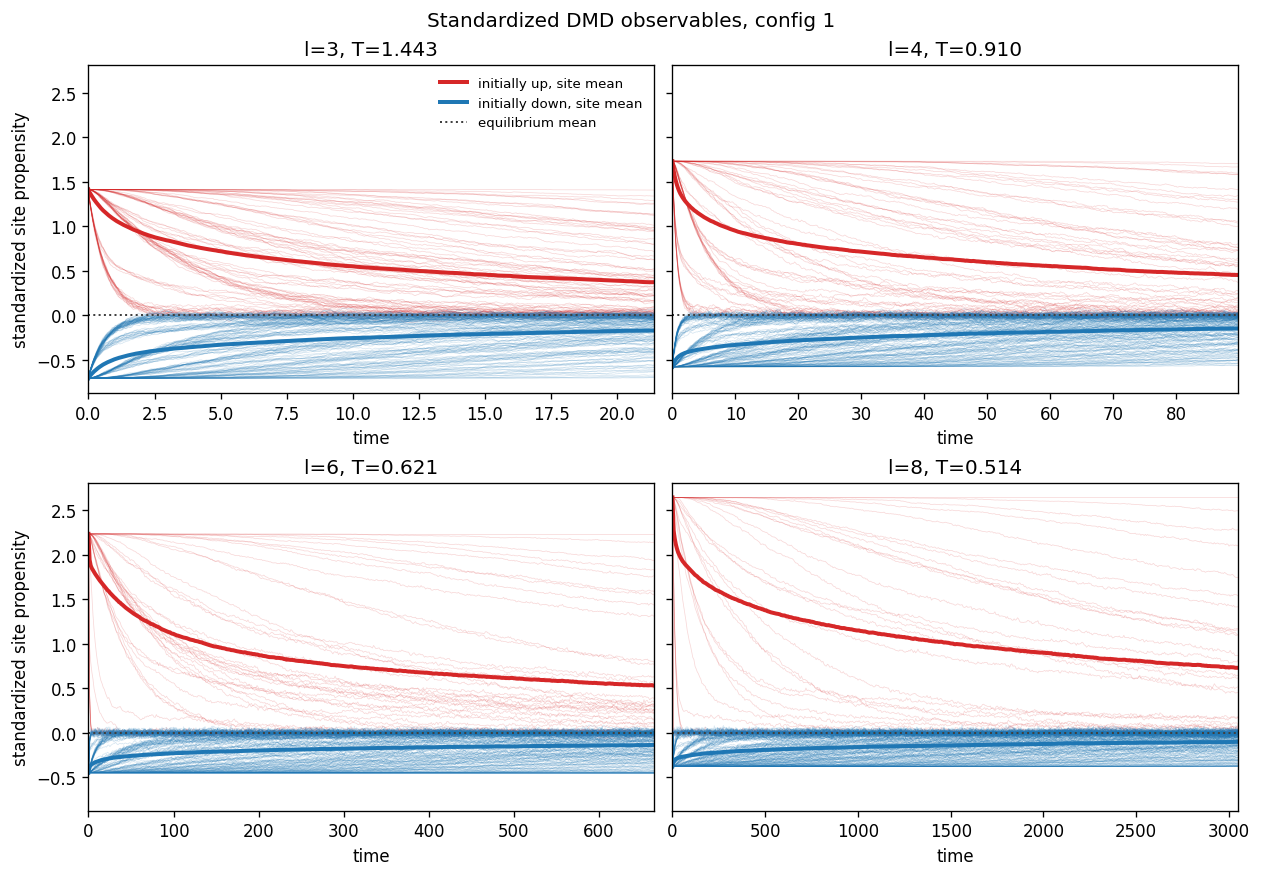

In [7]:
plot_config = 0
fig, axes_grid = plt.subplots(2, 2, figsize=(10.4, 7.2), sharex=False, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()

for ax, l_test in zip(axes, l_tests):
    res = temperature_results[l_test]
    params = res['params']
    times = params['times']
    Psi_plot = res['Psis'][plot_config]
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    # Skip the constant observable at column 0; plot standardized single-site observables.
    for idx in np.where(up_mask)[0]:
        ax.plot(times, Psi_plot[:, idx + 1], color='tab:red', lw=0.45, alpha=0.18)
    for idx in np.where(dn_mask)[0]:
        ax.plot(times, Psi_plot[:, idx + 1], color='tab:blue', lw=0.45, alpha=0.18)

    ax.plot(times, Psi_plot[:, 1:][:, up_mask].mean(axis=1), color='tab:red', lw=2.4,
            label='initially up, site mean')
    ax.plot(times, Psi_plot[:, 1:][:, dn_mask].mean(axis=1), color='tab:blue', lw=2.4,
            label='initially down, site mean')
    ax.axhline(0.0, color='0.25', ls=':', lw=1.2, label='equilibrium mean')

    ax.set_title(f'l={l_test}, T={params["T"]:.3f}')
    ax.set_xlabel('time')
    ax.margins(x=0)

axes[0].set_ylabel('standardized site propensity')
axes[2].set_ylabel('standardized site propensity')
axes[0].legend(frameon=False, loc='best', fontsize=8)
fig.suptitle(f'Standardized DMD observables, config {plot_config + 1}')


In [8]:
def fit_exact_dmd(X, Y, dt, energy=0.999, r_max=None):
    """Exact DMD with energy-based SVD truncation."""
    U, s, Vh = np.linalg.svd(X, full_matrices=False)
    cumulative = np.cumsum(s**2) / np.sum(s**2)
    r = int(np.searchsorted(cumulative, energy) + 1)
    if r_max is not None:
        r = min(r, int(r_max))

    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh.conj().T[:, :r]

    A_tilde = Ur.conj().T @ Y @ Vr @ np.diag(1.0 / sr)
    lam, W = np.linalg.eig(A_tilde)
    Phi = Y @ Vr @ np.diag(1.0 / sr) @ W
    mu = np.log(lam.astype(complex)) / dt

    return {
        'U': Ur,
        's': sr,
        'rank': r,
        'lambda': lam,
        'mu': mu,
        'Phi': Phi,
        'A_tilde': A_tilde,
    }


def mode_diagnostics(fit, Psis, times):
    """Amplitude and window-integrated contribution diagnostics per DMD mode."""
    Phi = fit['Phi']
    mu = fit['mu']

    amplitudes = np.stack([
        np.linalg.lstsq(Phi, Psis[j, 0], rcond=None)[0]
        for j in range(Psis.shape[0])
    ], axis=0)  # (n_configs, rank)

    # Ignore the constant observable when estimating whether a decaying mode matters.
    mode_shape_norm = np.linalg.norm(Phi[1:, :], axis=0)
    temporal_norm = np.sqrt(np.sum(np.abs(np.exp(np.outer(mu, times))) ** 2, axis=1))
    integrated_effect = np.abs(amplitudes) * mode_shape_norm[None, :] * temporal_norm[None, :]

    mean_abs_b = np.mean(np.abs(amplitudes), axis=0)
    mean_effect = np.mean(integrated_effect, axis=0)
    effect_fraction = mean_effect / np.sum(mean_effect) if np.sum(mean_effect) > 0 else mean_effect

    tau = np.full(mu.shape, np.inf, dtype=float)
    decaying = np.real(mu) < -1e-12
    tau[decaying] = 1.0 / np.abs(np.real(mu[decaying]))

    return {
        'amplitudes': amplitudes,
        'mean_abs_b': mean_abs_b,
        'mean_effect': mean_effect,
        'effect_fraction': effect_fraction,
        'tau': tau,
    }


for l_test, res in temperature_results.items():
    params = res['params']
    fit = fit_exact_dmd(res['X'], res['Y'], params['dt_record'], energy=0.999, r_max=80)
    mode_diag = mode_diagnostics(fit, res['Psis'], params['times'])
    res.update({'fit': fit, 'mode_diag': mode_diag})
    print(f'l={l_test}: rank={fit["rank"]}, T_window={params["T_window"]:.6g}')


l=3: rank=52, T_window=21.3953
l=4: rank=59, T_window=89.877
l=6: rank=62, T_window=664.746
l=8: rank=62, T_window=3049.52


The mode-contribution plot from `DMD.ipynb` is intentionally omitted in this temperature comparison.


In [9]:
def reconstruct_dmd(fit, psi0, times):
    """Reconstruct feature trajectory from one initial dictionary vector."""
    Phi = fit['Phi']
    mu = fit['mu']
    b = np.linalg.lstsq(Phi, psi0, rcond=None)[0]
    dynamics = np.exp(np.outer(mu, times)) * b[:, None]
    return (Phi @ dynamics).T


for l_test, res in temperature_results.items():
    params = res['params']
    fit = res['fit']
    Psis = res['Psis']
    mean_trajs = res['mean_trajs']
    times = params['times']
    sigma = np.sqrt(params['c_eq'] * (1.0 - params['c_eq']))

    Psi_hats = np.stack([
        reconstruct_dmd(fit, Psis[j, 0], times)
        for j in range(n_configs)
    ], axis=0)

    mean_hats = np.real(Psi_hats[:, :, 1:] * sigma + params['c_eq'])
    rel_errs = np.linalg.norm(mean_hats - mean_trajs, axis=(1, 2)) / np.linalg.norm(mean_trajs - params['c_eq'], axis=(1, 2))

    res.update({'Psi_hats': Psi_hats, 'mean_hats': mean_hats, 'rel_errs': rel_errs})

    print(f'l={l_test}: relative reconstruction error, mean +/- sd: {rel_errs.mean():.3e} +/- {rel_errs.std():.3e}')


l=3: relative reconstruction error, mean +/- sd: 3.752e-02 +/- 2.150e-03
l=4: relative reconstruction error, mean +/- sd: 4.436e-02 +/- 4.474e-03
l=6: relative reconstruction error, mean +/- sd: 9.554e-02 +/- 1.585e-02
l=8: relative reconstruction error, mean +/- sd: 9.529e-02 +/- 2.292e-02


Text(0.5, 0.98, 'Pooled-DMD reconstruction, config 1')

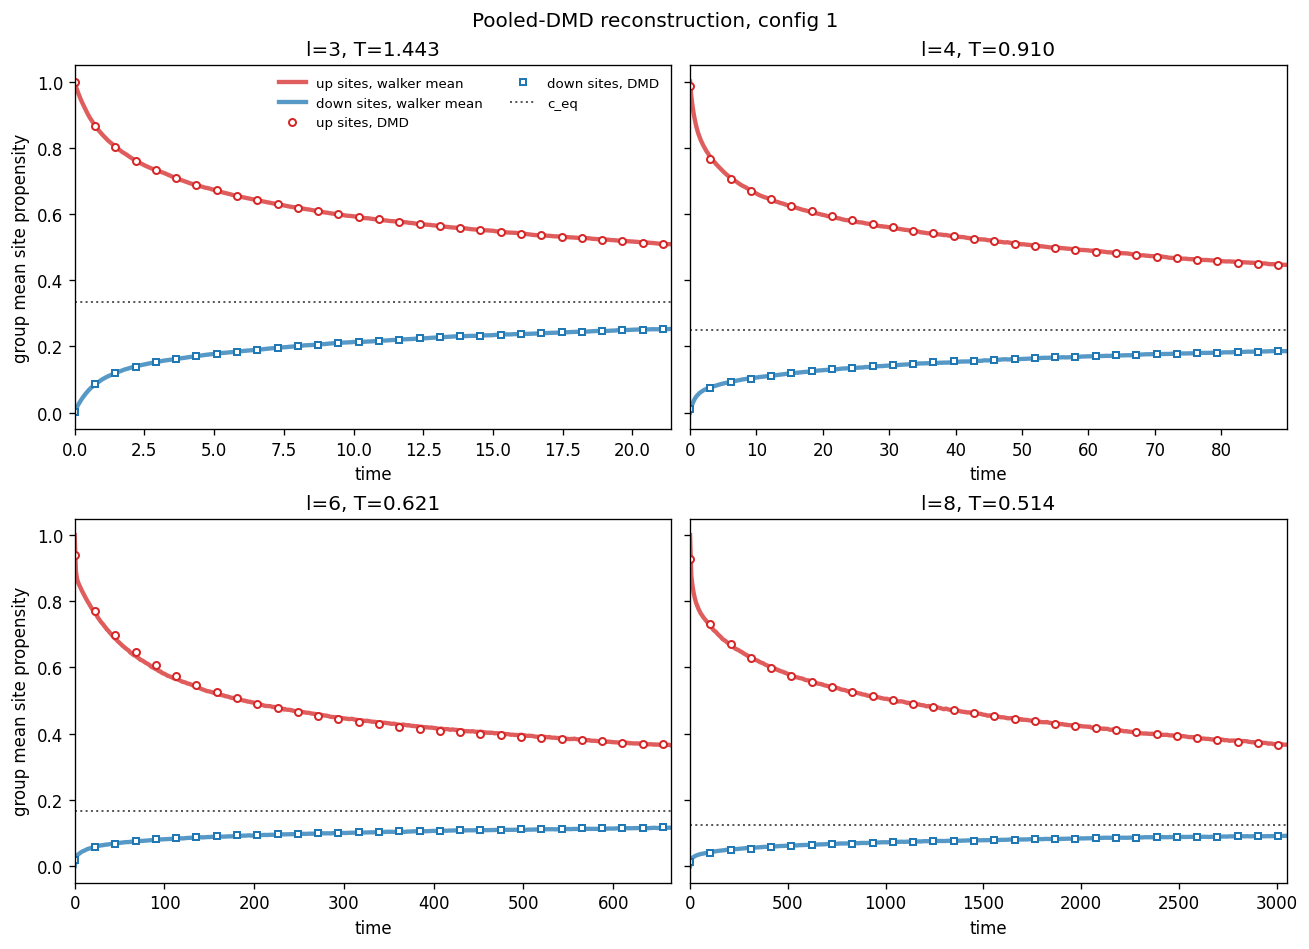

In [10]:
plot_config = 0
fig, axes_grid = plt.subplots(2, 2, figsize=(10.8, 7.8), sharex=False, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()

for ax, l_test in zip(axes, l_tests):
    res = temperature_results[l_test]
    params = res['params']
    times = params['times']
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    mean_traj_plot = res['mean_trajs'][plot_config]
    mean_hat_plot = res['mean_hats'][plot_config]

    mean_up = mean_traj_plot[:, up_mask].mean(axis=1)
    mean_dn = mean_traj_plot[:, dn_mask].mean(axis=1)
    mean_up_hat = mean_hat_plot[:, up_mask].mean(axis=1)
    mean_dn_hat = mean_hat_plot[:, dn_mask].mean(axis=1)
    marker_stride = max(1, len(times) // 28)

    ax.plot(times, mean_up, color='tab:red', lw=2.6, alpha=0.75,
            label='up sites, walker mean')
    ax.plot(times, mean_dn, color='tab:blue', lw=2.6, alpha=0.75,
            label='down sites, walker mean')
    ax.plot(times, mean_up_hat, color='tab:red', marker='o', ls='None', ms=4.2,
            mfc='white', mec='tab:red', mew=1.2, markevery=marker_stride,
            label='up sites, DMD')
    ax.plot(times, mean_dn_hat, color='tab:blue', marker='s', ls='None', ms=4.0,
            mfc='white', mec='tab:blue', mew=1.2, markevery=marker_stride,
            label='down sites, DMD')
    ax.axhline(params['c_eq'], color='0.35', ls=':', lw=1.2, label='c_eq')

    ax.set_title(f'l={l_test}, T={params["T"]:.3f}')
    ax.set_xlabel('time')
    ax.margins(x=0)

axes[0].set_ylabel('group mean site propensity')
axes[2].set_ylabel('group mean site propensity')
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle(f'Pooled-DMD reconstruction, config {plot_config + 1}')


Text(0.5, 0.98, 'Per-site pooled-DMD reconstruction, config 1')

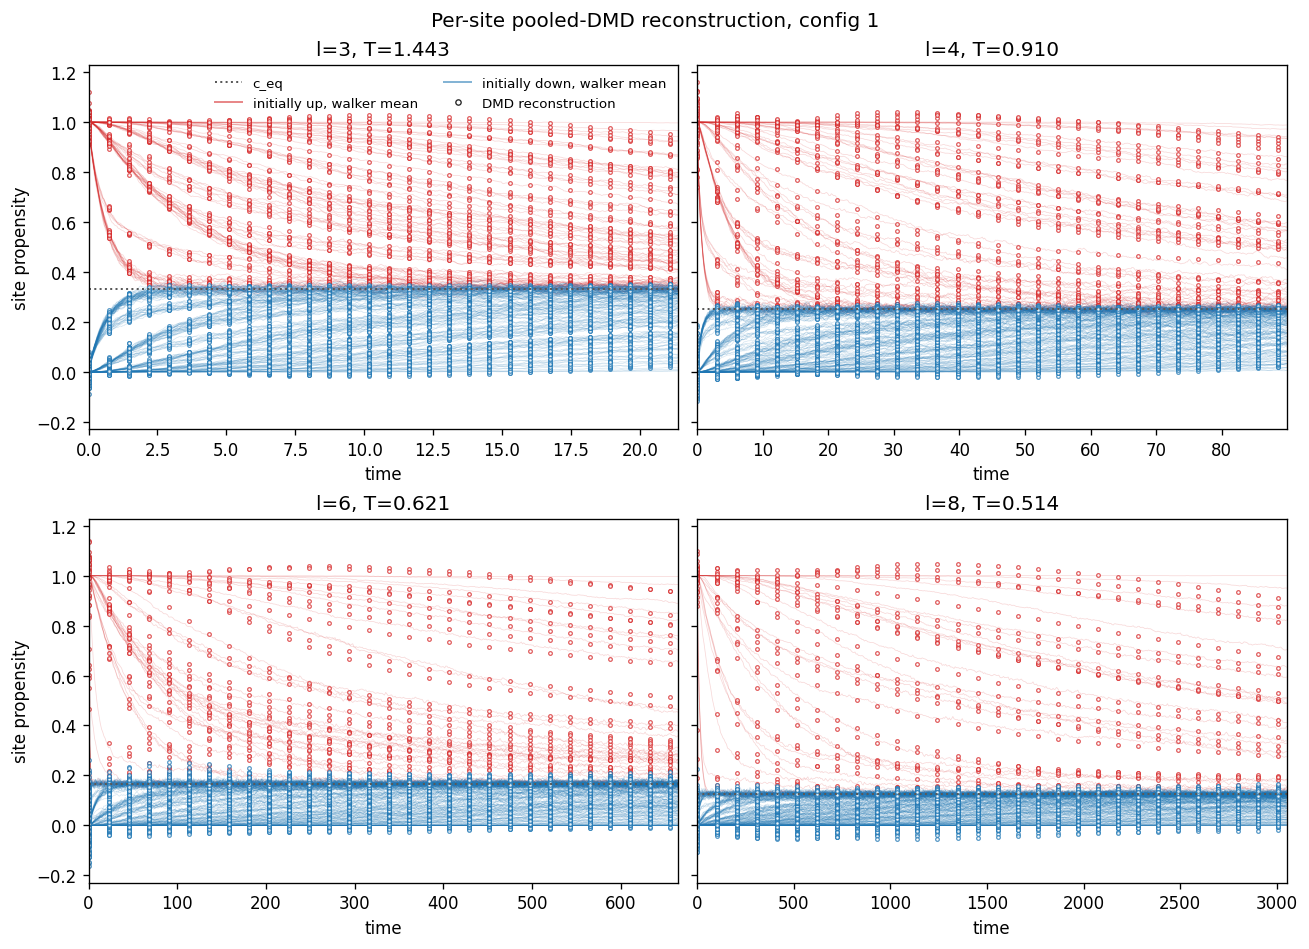

In [11]:
plot_config = 0
fig, axes_grid = plt.subplots(2, 2, figsize=(10.8, 7.8), sharex=False, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()

for ax, l_test in zip(axes, l_tests):
    res = temperature_results[l_test]
    params = res['params']
    times = params['times']
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    mean_traj_plot = res['mean_trajs'][plot_config]
    mean_hat_plot = res['mean_hats'][plot_config]
    marker_stride = max(1, len(times) // 28)

    for idx in np.where(up_mask)[0]:
        ax.plot(times, mean_traj_plot[:, idx], color='tab:red', lw=0.45, alpha=0.18)
        ax.plot(times, mean_hat_plot[:, idx], color='tab:red', marker='o', ls='None', ms=2.2,
                mfc='white', mec='tab:red', mew=0.75, alpha=0.75, markevery=marker_stride)
    for idx in np.where(dn_mask)[0]:
        ax.plot(times, mean_traj_plot[:, idx], color='tab:blue', lw=0.45, alpha=0.18)
        ax.plot(times, mean_hat_plot[:, idx], color='tab:blue', marker='o', ls='None', ms=2.2,
                mfc='white', mec='tab:blue', mew=0.75, alpha=0.75, markevery=marker_stride)

    ax.axhline(params['c_eq'], color='0.35', ls=':', lw=1.2, label='c_eq')
    ax.set_title(f'l={l_test}, T={params["T"]:.3f}')
    ax.set_xlabel('time')
    ax.margins(x=0)

# Proxy artists keep the legend readable without labeling every site.
axes[0].plot([], [], color='tab:red', lw=1.2, alpha=0.55, label='initially up, walker mean')
axes[0].plot([], [], color='tab:blue', lw=1.2, alpha=0.55, label='initially down, walker mean')
axes[0].plot([], [], color='0.15', marker='o', ls='None', ms=3.2,
             mfc='white', mec='0.15', mew=0.8, label='DMD reconstruction')
axes[0].set_ylabel('site propensity')
axes[2].set_ylabel('site propensity')
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle(f'Per-site pooled-DMD reconstruction, config {plot_config + 1}')


l=3: pseudospectrum grid computed in 0.9s
l=4: pseudospectrum grid computed in 1.2s
l=6: pseudospectrum grid computed in 1.4s
l=8: pseudospectrum grid computed in 1.3s


Text(0.5, 0.98, 'single-site pooled DMD spectra by temperature')

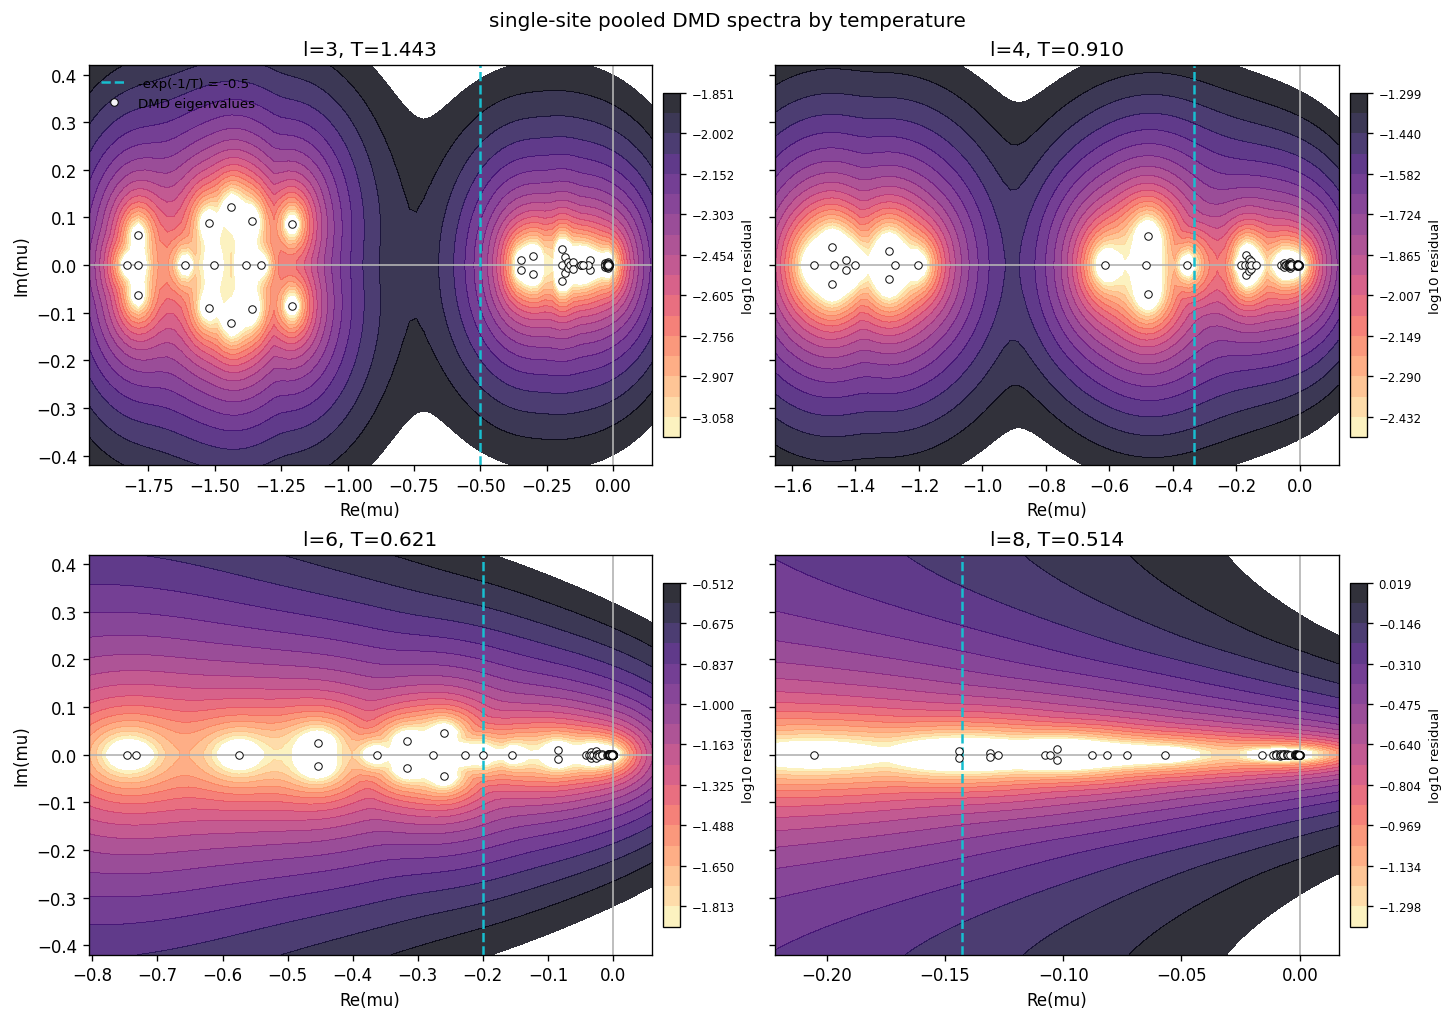

In [14]:
def dmd_pseudospectrum_mu(fit, dt, n_real=80, n_imag=60, real_grid=None, imag_grid=None):
    """Finite-dimensional DMD pseudospectrum in the continuous-time mu plane."""
    A = fit['A_tilde']
    if real_grid is None or imag_grid is None:
        mu = fit['mu']
        real = np.real(mu[np.isfinite(mu)])
        imag = np.imag(mu[np.isfinite(mu)])

        if real_grid is None:
            re_span = max(real.max() - real.min(), 1e-6)
            real_grid = np.linspace(real.min() - 0.08 * re_span,
                                    max(0.0, real.max()) + 0.08 * re_span,
                                    n_real)

        if imag_grid is None:
            im_span = max(imag.max() - imag.min(), 1e-6)
            imag_grid = np.linspace(imag.min() - 0.12 * im_span,
                                    imag.max() + 0.12 * im_span,
                                    n_imag)

    eye = np.eye(A.shape[0], dtype=complex)
    sigma_min = np.empty((len(imag_grid), len(real_grid)), dtype=float)
    for j, im in enumerate(imag_grid):
        for i, re in enumerate(real_grid):
            z = np.exp((re + 1j * im) * dt)
            sigma_min[j, i] = np.linalg.svd(z * eye - A, compute_uv=False)[-1]

    return real_grid, imag_grid, np.log10(np.maximum(sigma_min, 1e-16))


plot_pseudospectrum = True

# Shared Im(mu) range for visual comparison; each temperature gets its own Re(mu)
# range and its own residual color scale.
imag_grid = np.linspace(-0.42, 0.42, 60)

if plot_pseudospectrum:
    for l_test, res in temperature_results.items():
        params = res['params']
        mu = res['fit']['mu']
        finite_mu = mu[np.isfinite(mu)]
        real_vals = np.real(finite_mu)

        re_span = max(real_vals.max() - real_vals.min(), 1e-6)
        real_grid = np.linspace(real_vals.min() - 0.08 * re_span,
                                max(0.0, real_vals.max()) + 0.08 * re_span,
                                80)

        t0 = time.time()
        re_grid, im_grid, log_sigma_min = dmd_pseudospectrum_mu(
            res['fit'],
            params['dt_record'],
            real_grid=real_grid,
            imag_grid=imag_grid,
        )
        res['pseudospectrum'] = {
            're_grid': re_grid,
            'im_grid': im_grid,
            'log_sigma_min': log_sigma_min,
        }
        print(f'l={l_test}: pseudospectrum grid computed in {time.time() - t0:.1f}s')

fig, axes_grid = plt.subplots(
    2, 2,
    figsize=(12.0, 8.4),
    sharex=False,
    sharey=True,
    constrained_layout=True,
)
axes = axes_grid.ravel()

for ax, l_test in zip(axes, l_tests):
    res = temperature_results[l_test]
    params = res['params']
    mu = res['fit']['mu']

    cf = None
    if plot_pseudospectrum:
        ps = res['pseudospectrum']
        log_sigma_min = ps['log_sigma_min']
        levels = np.linspace(np.nanpercentile(log_sigma_min, 5),
                             np.nanpercentile(log_sigma_min, 95), 18)
        cf = ax.contourf(ps['re_grid'], ps['im_grid'], log_sigma_min,
                         levels=levels, cmap='magma_r', alpha=0.82)

    ax.axvline(0, color='0.7', lw=1)
    ax.axhline(0, color='0.7', lw=1)
    ax.axvline(params['mu_micro'], color='tab:cyan', ls='--', lw=1.5,
               label=f'-exp(-1/T) = {params["mu_micro"]:.3g}')
    ax.plot(np.real(mu), np.imag(mu), 'o', ms=4.5, color='white', mec='black', mew=0.6,
            alpha=0.95, label='DMD eigenvalues')

    ax.set_title(f'l={l_test}, T={params["T"]:.3f}')
    ax.set_xlabel('Re(mu)')
    ax.set_xlim(res['pseudospectrum']['re_grid'][0], res['pseudospectrum']['re_grid'][-1])
    ax.set_ylim(imag_grid[0], imag_grid[-1])

    if cf is not None:
        cbar = fig.colorbar(cf, ax=ax, location='right', shrink=0.86, pad=0.02)
        cbar.set_label('log10 residual', fontsize=8)
        cbar.ax.tick_params(labelsize=7)

axes[0].set_ylabel('Im(mu)')
axes[2].set_ylabel('Im(mu)')
axes[0].legend(frameon=False, loc='best', fontsize=8)

fig.suptitle('single-site pooled DMD spectra by temperature')

## Next extension

Once this pooled single-site temperature comparison behaves sensibly, the next step is to replace `single_site_dictionary` with the downward-closed local cluster dictionary from `AGENTS.md`: evaluate products on each walker trajectory first, average those products over walkers, then apply the exact equilibrium centering/scaling for each cluster order.
